In [1]:


import pandas as pd
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt



In [2]:
excel_filename = "pipeline_inputs.xlsx"

# 1. READ EXCEL INPUTS

print(f"Reading inputs from '{excel_filename}'...")
df_glob = pd.read_excel(excel_filename, sheet_name="Global_Parameters").fillna("")
params = dict(zip(df_glob["Parameter"], df_glob["Value"]))

df_pipes = pd.read_excel(excel_filename, sheet_name="Pipes")
df_schedule = pd.read_excel(excel_filename, sheet_name="Flow_Schedule")

# Extract Gas Parameters
gas_name = str(params.get("Gas_Name", "Natural Gas"))
mw_val   = float(params.get("MW_kg_kmol", 18.0))
gamma_val= float(params.get("Gamma", 1.30))
z_val    = float(params.get("Z_factor", 0.85))
mu_jt_raw = params.get("mu_jt", 4.0e-6)
mu_jt_val = float(mu_jt_raw) if str(mu_jt_raw).strip() != "" else 4.0e-6
cp_raw   = params.get("Cp_J_kgK", "")
cp_val   = float(cp_raw) if str(cp_raw).strip() != "" else None

# Extract Conditions & Simulation Parameters
P_outlet_target = float(params.get("P_outlet_target_Pa", 1200000.0))
T_inlet_init    = float(params.get("T_inlet_K", 283.15))
U               = float(params.get("U_heat_transfer", 2.5))
T_ground        = float(params.get("T_ground_K", 283.15))
t_total         = float(params.get("t_total_s", 200.0))
dt              = float(params.get("dt_s", 2.0))


theta = float(params.get("Theta", 0.8))
# Build Pipes List 
pipes = []
for index, row in df_pipes.iterrows():
    pipes.append({
        'L': float(row['Length_m']),
        'D': float(row['Diameter_m']),
        'f': float(row['Friction_f']),
        'elev': float(row['Elevation_Change_m']),
        'N': int(row['Nodes'])
    })

# Build Flow Schedule
schedule = list(zip(df_schedule["Time_s"], df_schedule["Mass_Flow_kg_s"]))
schedule.sort(key=lambda x: x[0])  # Sort chronologically

def get_scheduled_flow(current_time):
    """Original step-function lookup (kept for reference/comparison)."""
    current_flow = schedule[0][1]
    for t_step, flow in schedule:
        if current_time >= t_step:
            current_flow = flow
        else:
            break
    return current_flow

 
 
M_init = get_scheduled_flow(0.0)  # Start the simulation using the t=0 flow rate


Reading inputs from 'pipeline_inputs.xlsx'...


In [3]:
class Gas:
    R_UNIVERSAL=8314.46

    def __init__(self,name,MW,gamma,Z_factor=0.85,mu_JT=4.0e-6,cp_override=None):
        self.name = name
        self.MW = MW
        self.gamma = gamma
        self.Z = Z_factor
        self.mu_JT= mu_JT
        
        # Specific Gas Constant [J/(kg K)]
        self.R_gas = self.R_UNIVERSAL / self.MW 

        # Specific Heats
        if cp_override is not None:
            self.cp_gas = cp_override
            self.cv_gas = self.cp_gas / self.gamma
        else:
            # Derived from Cp - Cv = R and Cp/Cv = gamma
            self.cp_gas = self.R_gas * self.gamma / (self.gamma - 1.0)
            self.cv_gas = self.cp_gas / self.gamma

gas = Gas(name=gas_name, MW=mw_val, gamma=gamma_val, Z_factor=z_val,mu_JT=mu_jt_val, cp_override=cp_val)
print(f"--- Starting Transient Backward Simulation for {gas.name} ---")        

--- Starting Transient Backward Simulation for Natural Gas ---


In [4]:
# 3. GENERATE SPATIAL ARRAYS
g = 9.81
P_ref = 101325 

N_nodes = sum([p['N'] - 1 for p in pipes]) + 1 

x_coords = np.zeros(N_nodes)
elevation = np.zeros(N_nodes)
D_arr = np.zeros(N_nodes - 1)
A_arr = np.zeros(N_nodes - 1)
f_arr = np.zeros(N_nodes - 1)
dx_arr = np.zeros(N_nodes - 1)

node_idx = 0
current_x = 0.0
current_elev = 0.0
junctions = [] 

for p in pipes:
    N_seg = p['N'] - 1
    dx_p = p['L'] / N_seg
    dz_p = p['elev'] / N_seg

    for s in range(N_seg):
        D_arr[node_idx]  = p['D']
        A_arr[node_idx]  = np.pi * p['D']**2 / 4.0
        f_arr[node_idx]  = p['f']
        dx_arr[node_idx] = dx_p

        x_coords[node_idx + 1]  = current_x + dx_p
        elevation[node_idx + 1] = current_elev + dz_p

        current_x += dx_p
        current_elev += dz_p
        node_idx += 1
        
    junctions.append(current_x)

In [5]:
# functions to use
def get_fluid_state(P_val,T_val):
    
    
    Z=gas.Z
    rho_val=P_val/(Z* gas.R_gas *T_val)
    drho_dP=1.0 / (Z * gas.R_gas * T_val)
    drho_dT = -P_val / (Z * gas.R_gas * T_val**2)
    return rho_val,drho_dP,drho_dT

def get_momentum_terms(P_val, M_val, T_val, sin_alpha, D_loc, A_loc, f_loc):
    rho, drho_dP, drho_dT = get_fluid_state(P_val, T_val)
    F_f = (f_loc * M_val * abs(M_val)) / (2 * D_loc * rho * A_loc)
    dFf_dM = (f_loc * abs(M_val)) / (D_loc * rho * A_loc)
    dFf_dP = -(F_f / rho) * drho_dP
    dFf_dT = -(F_f / rho) * drho_dT
    
    F_g = A_loc * rho * g * sin_alpha
    dFg_dP = A_loc * g * sin_alpha * drho_dP
    dFg_dT = A_loc * g * sin_alpha * drho_dT
    
    C_v = (M_val**2) / (rho * A_loc)
    dCv_dM = (2 * M_val) / (rho * A_loc)
    dCv_dP = -(C_v / rho) * drho_dP
    dCv_dT = -(C_v / rho) * drho_dT
    
    return ((F_f, dFf_dP, dFf_dM, dFf_dT), (F_g, dFg_dP, 0.0, dFg_dT), (C_v, dCv_dP, dCv_dM, dCv_dT))

def get_energy_terms(P_val, M_val, T_val, elev_val, D_loc, A_loc):
    rho, drho_dP, drho_dT = get_fluid_state(P_val, T_val)
 
    # Enthalpy with Joule-Thomson correction
    h      = gas.cp_gas * T_val - gas.mu_JT * gas.cp_gas * P_val
    dh_dP  = -gas.mu_JT * gas.cp_gas
    dh_dT  = gas.cp_gas
 
    # Internal energy  u = h - P/rho
    u      = h - (P_val / rho)
    du_dP  = dh_dP - (1.0 / rho) + (P_val / rho**2) * drho_dP
    du_dT  = dh_dT                + (P_val / rho**2) * drho_dT
 
    #  Accumulation term E_acc  [J/m]  (energy per unit length) 
    KE     = M_val**2 / (2.0 * rho * A_loc)
    PE     = rho * A_loc * g * elev_val
 
    E_acc      = rho * A_loc * u + KE + PE
    dEacc_dP   = (drho_dP * A_loc * u + rho * A_loc * du_dP
                  - (M_val**2 / (2.0 * rho**2 * A_loc)) * drho_dP
                  + drho_dP * A_loc * g * elev_val)
    dEacc_dM   = M_val / (rho * A_loc)
    dEacc_dT   = (drho_dT * A_loc * u + rho * A_loc * du_dT
                  - (M_val**2 / (2.0 * rho**2 * A_loc)) * drho_dT
                  + drho_dT * A_loc * g * elev_val)
 
    # Flux term E_flux  [W]  (energy flow rate) 
    E_flux     = M_val * h + M_val**3 / (2.0 * rho**2 * A_loc**2) + M_val * g * elev_val
    dEflux_dP  = M_val * dh_dP - (M_val**3 / (rho**3 * A_loc**2)) * drho_dP
    dEflux_dM  = h + 3.0 * M_val**2 / (2.0 * rho**2 * A_loc**2) + g * elev_val
    dEflux_dT  = M_val * dh_dT - (M_val**3 / (rho**3 * A_loc**2)) * drho_dT
 
    #  Heat loss Q  [W/m]  (positive = heat leaving the pipe) 
    Q          = np.pi * D_loc * U * (T_val - T_ground)
    dQ_dT      = np.pi * D_loc * U
 
    return (
        (E_acc,   dEacc_dP,  dEacc_dM,  dEacc_dT),
        (E_flux,  dEflux_dP, dEflux_dM, dEflux_dT),
        (Q,       0.0,       0.0,        dQ_dT),
    )
 
 

    

In [6]:
#initialization of state vectors
P = np.zeros(N_nodes)
M = np.ones(N_nodes) * M_init
T = np.ones(N_nodes) * T_inlet_init


P[-1]=max(P_outlet_target,101325)

for i in range(N_nodes-1,0,-1):
    dx_seg = dx_arr[i-1]
    A_seg  = A_arr[i-1]
    D_seg  = D_arr[i-1]
    f_seg  = f_arr[i-1]
    sin_alpha = (elevation[i] - elevation[i-1]) / dx_seg
    
    rho_est, _, _ = get_fluid_state(P[i], T_inlet_init)
    
    # Calculate pressure drops
    dP_fric = -(f_seg * M_init * abs(M_init)) / (2 * D_seg * rho_est * A_seg**2)
    dP_grav = -rho_est * g * sin_alpha
    
    # Calculate the new pressure, but CLAMP it at 1 atm minimum to prevent division by zero!
    P[i-1] = max(P[i] - (dP_fric + dP_grav) * dx_seg, 101325.0)
T[0] = T_inlet_init
for i in range(1, N_nodes):
    dx_seg = dx_arr[i-1]
    D_seg  = D_arr[i-1]
    
    dP_dx = (P[i] - P[i-1]) / dx_seg
    lambda_temp = (np.pi * D_seg * U) / (M_init * gas.cp_gas)
    
    dT_dx = -lambda_temp * (T[i-1] - T_ground) + gas.mu_JT * dP_dx
    T[i] = T[i-1] + dT_dx * dx_seg


mid_node=N_nodes//2


In [7]:
# Storage for plotting
history_t = []
history_P_inlet, history_P_outlet = [], []
history_M_outlet,history_M_inlet = [],[]
history_P_mid=[]
history_mass_balance = []   
history_line_pack    = [] 
history_T_inlet, history_T_outlet, history_T_mid = [], [], []

In [8]:

time=0.0

while time <= t_total:
    if np.isnan(P).any() or np.isnan(M).any():
        print(f"\n[CRITICAL ERROR] The math solver returned NaNs at time = {time}s!")
        break

    target_mass_flow = get_scheduled_flow(time)

    
    # Calculate Line Pack over piece-wise segments
    rho_field = np.array([get_fluid_state(P[i], T[i])[0] for i in range(N_nodes)])
    line_pack = 0.0
    for i in range(N_nodes - 1):
        rho_avg = (rho_field[i] + rho_field[i+1]) / 2.0
        line_pack += rho_avg * A_arr[i] * dx_arr[i]

    history_t.append(time)
    history_P_inlet.append(P[0])
    history_P_outlet.append(P[-1])
    history_M_inlet.append(M[0])
    history_M_outlet.append(M[-1])
    history_line_pack.append(line_pack)
    history_P_mid.append(P[mid_node])
    history_T_inlet.append(T[0])
    history_T_outlet.append(T[-1])
    history_T_mid.append(T[mid_node])

    if len(history_line_pack) >= 2:
        dlp_dt = (history_line_pack[-1] - history_line_pack[-2]) / dt
        imbalance = M[0] - M[-1] - dlp_dt   
    else:
        imbalance = 0.0
    
    history_mass_balance.append(imbalance)
    
    P_old = P.copy()
    M_old = M.copy()
    T_old = T.copy()

    J   = sp.lil_matrix((3 * N_nodes, 3 * N_nodes))
    RHS = np.zeros(3 * N_nodes)

    
    # BOUNDARY CONDITIONS (Inlet)

    J[0, 1] = 1.0; RHS[0] = target_mass_flow - M[0]           
    J[1, 2] = 1.0; RHS[1] = T_inlet_init - T[0]   

    
    for i in range(N_nodes - 1):
        # Extract Local Segment Properties
        dx_seg = dx_arr[i]
        A_seg  = A_arr[i]
        D_seg  = D_arr[i]
        f_seg  = f_arr[i]
        
        row_mass = 3 * i + 2
        row_mom  = 3 * i + 3
        row_eng  = 3 * i + 4

        cPi,  cMi,  cTi  = 3*i,   3*i+1, 3*i+2
        cPi1, cMi1, cTi1 = 3*i+3, 3*i+4, 3*i+5

        Pi,  Mi,  Ti  = P[i],    M[i],    T[i]
        Pi1, Mi1, Ti1 = P[i+1],  M[i+1],  T[i+1]
        sin_alpha = (elevation[i+1] - elevation[i]) / dx_seg

        rho_i,   drho_dP_i,   drho_dT_i   = get_fluid_state(Pi,  Ti)
        rho_i1,  drho_dP_i1,  drho_dT_i1  = get_fluid_state(Pi1, Ti1)

        Ff_i,  Fg_i,  Cv_i  = get_momentum_terms(Pi,  Mi,  Ti,  sin_alpha, D_seg, A_seg, f_seg)
        Ff_i1, Fg_i1, Cv_i1 = get_momentum_terms(Pi1, Mi1, Ti1, sin_alpha, D_seg, A_seg, f_seg)

        Ea_i,  Ef_i,  Q_i   = get_energy_terms(Pi,  Mi,  Ti,  elevation[i],   D_seg, A_seg)
        Ea_i1, Ef_i1, Q_i1  = get_energy_terms(Pi1, Mi1, Ti1, elevation[i+1], D_seg, A_seg)

        rho_i_old,  _, _ = get_fluid_state(P_old[i],   T_old[i])
        rho_i1_old, _, _ = get_fluid_state(P_old[i+1], T_old[i+1])

        Ff_io,  Fg_io,  Cv_io  = get_momentum_terms(P_old[i],   M_old[i],   T_old[i],   sin_alpha, D_seg, A_seg, f_seg)
        Ff_i1o, Fg_i1o, Cv_i1o = get_momentum_terms(P_old[i+1], M_old[i+1], T_old[i+1], sin_alpha, D_seg, A_seg, f_seg)

        Ea_io,  Ef_io,  Q_io   = get_energy_terms(P_old[i],   M_old[i],   T_old[i],   elevation[i],   D_seg, A_seg)
        Ea_i1o, Ef_i1o, Q_i1o  = get_energy_terms(P_old[i+1], M_old[i+1], T_old[i+1], elevation[i+1], D_seg, A_seg)

        # Mass box eqn:
        J[row_mass, cPi]  = (A_seg / (2*dt)) * drho_dP_i
        J[row_mass, cMi]  = -theta / dx_seg
        J[row_mass, cTi]  = (A_seg / (2*dt)) * drho_dT_i
        J[row_mass, cPi1] = (A_seg / (2*dt)) * drho_dP_i1
        J[row_mass, cMi1] =  theta / dx_seg
        J[row_mass, cTi1] = (A_seg / (2*dt)) * drho_dT_i1

        temporal_mass    = ((rho_i + rho_i1) / 2 - (rho_i_old + rho_i1_old) / 2) * A_seg / dt
        spatial_mass_new =  theta       * (Mi1 - Mi)          / dx_seg
        spatial_mass_old = (1 - theta)  * (M_old[i+1] - M_old[i]) / dx_seg
        RHS[row_mass]    = -(temporal_mass + spatial_mass_new + spatial_mass_old)

        # Momentum eqn 
        J[row_mom, cPi]  = (-(theta*A_seg)/dx_seg  - (theta*Cv_i[1])/dx_seg  + (theta/2)*(Fg_i[1]  + Ff_i[1]))
        J[row_mom, cMi]  = (  1.0/(2*dt)       - (theta*Cv_i[2])/dx_seg  + (theta/2)*(Fg_i[2]  + Ff_i[2]))
        J[row_mom, cTi]  = (               - (theta*Cv_i[3])/dx_seg  + (theta/2)*(Fg_i[3]  + Ff_i[3]))
        J[row_mom, cPi1] = (  (theta*A_seg)/dx_seg + (theta*Cv_i1[1])/dx_seg + (theta/2)*(Fg_i1[1] + Ff_i1[1]))
        J[row_mom, cMi1] = (  1.0/(2*dt)       + (theta*Cv_i1[2])/dx_seg + (theta/2)*(Fg_i1[2] + Ff_i1[2]))
        J[row_mom, cTi1] = (                 (theta*Cv_i1[3])/dx_seg + (theta/2)*(Fg_i1[3] + Ff_i1[3]))

        temporal_mom     = ((Mi + Mi1) / 2 - (M_old[i] + M_old[i+1]) / 2) / dt
        spatial_mom_new  = theta * (A_seg * (Pi1 - Pi) / dx_seg + (Cv_i1[0] - Cv_i[0]) / dx_seg + (Fg_i[0]  + Fg_i1[0])  / 2 + (Ff_i[0]  + Ff_i1[0])  / 2)
        spatial_mom_old  = (1 - theta) * (A_seg * (P_old[i+1] - P_old[i]) / dx_seg + (Cv_i1o[0] - Cv_io[0]) / dx_seg + (Fg_io[0]  + Fg_i1o[0])  / 2 + (Ff_io[0]  + Ff_i1o[0])  / 2)
        RHS[row_mom] = -(temporal_mom + spatial_mom_new + spatial_mom_old)

       # Energy eqn:
        J[row_eng, cPi]  = (Ea_i[1]  * dx_seg / (2 * dt) - theta * Ef_i[1]  + theta * dx_seg / 2 * Q_i[1])
        J[row_eng, cMi]  = (Ea_i[2]  * dx_seg / (2 * dt) - theta * Ef_i[2]  + theta * dx_seg / 2 * Q_i[2])
        J[row_eng, cTi]  = (Ea_i[3]  * dx_seg / (2 * dt) - theta * Ef_i[3]  + theta * dx_seg / 2 * Q_i[3])
        J[row_eng, cPi1] = (Ea_i1[1] * dx_seg / (2 * dt) + theta * Ef_i1[1] + theta * dx_seg / 2 * Q_i1[1])
        J[row_eng, cMi1] = (Ea_i1[2] * dx_seg / (2 * dt) + theta * Ef_i1[2] + theta * dx_seg / 2 * Q_i1[2])
        J[row_eng, cTi1] = (Ea_i1[3] * dx_seg / (2 * dt) + theta * Ef_i1[3] + theta * dx_seg / 2 * Q_i1[3])
 
        temporal_eng    = ((Ea_i[0] + Ea_i1[0]) / 2.0 - (Ea_io[0] + Ea_i1o[0]) / 2.0) * dx_seg / dt
        spatial_eng_new = theta * (
            (Ef_i1[0] - Ef_i[0])
            + (Q_i[0] + Q_i1[0]) / 2.0 * dx_seg   
        )
        spatial_eng_old = (1 - theta) * (
            (Ef_i1o[0] - Ef_io[0])
            + (Q_io[0] + Q_i1o[0]) / 2.0 * dx_seg 
        )
        RHS[row_eng] = -(temporal_eng + spatial_eng_new + spatial_eng_old)
    J[-1, -3] = 1.0     
    RHS[-1] = P_outlet_target - P[-1]   

    # matrix solving with scaling
    J_csr = J.tocsr()
    col_scales = np.zeros(3 * N_nodes)
    col_scales[0::3] = 1e6   
    col_scales[1::3] = 1e1   
    col_scales[2::3] = 1e2   
    S_col = sp.diags(col_scales)
    J_csr = J_csr.dot(S_col)

    row_maxes = np.abs(J_csr).max(axis=1).toarray().flatten()
    row_maxes[row_maxes == 0] = 1.0
    S_row     = sp.diags(1.0 / row_maxes)
    J_scaled  = S_row.dot(J_csr)
    RHS_scaled = S_row.dot(RHS)

    Delta_scaled = spla.spsolve(J_scaled, RHS_scaled)
    Delta        = Delta_scaled * col_scales

    P = np.clip(P + Delta[0::3], P_ref, 1e8)
    M = np.clip(M + Delta[1::3], -5000.0, 5000.0)
    T = np.clip(T + Delta[2::3], 273.15, 700)

    time += dt

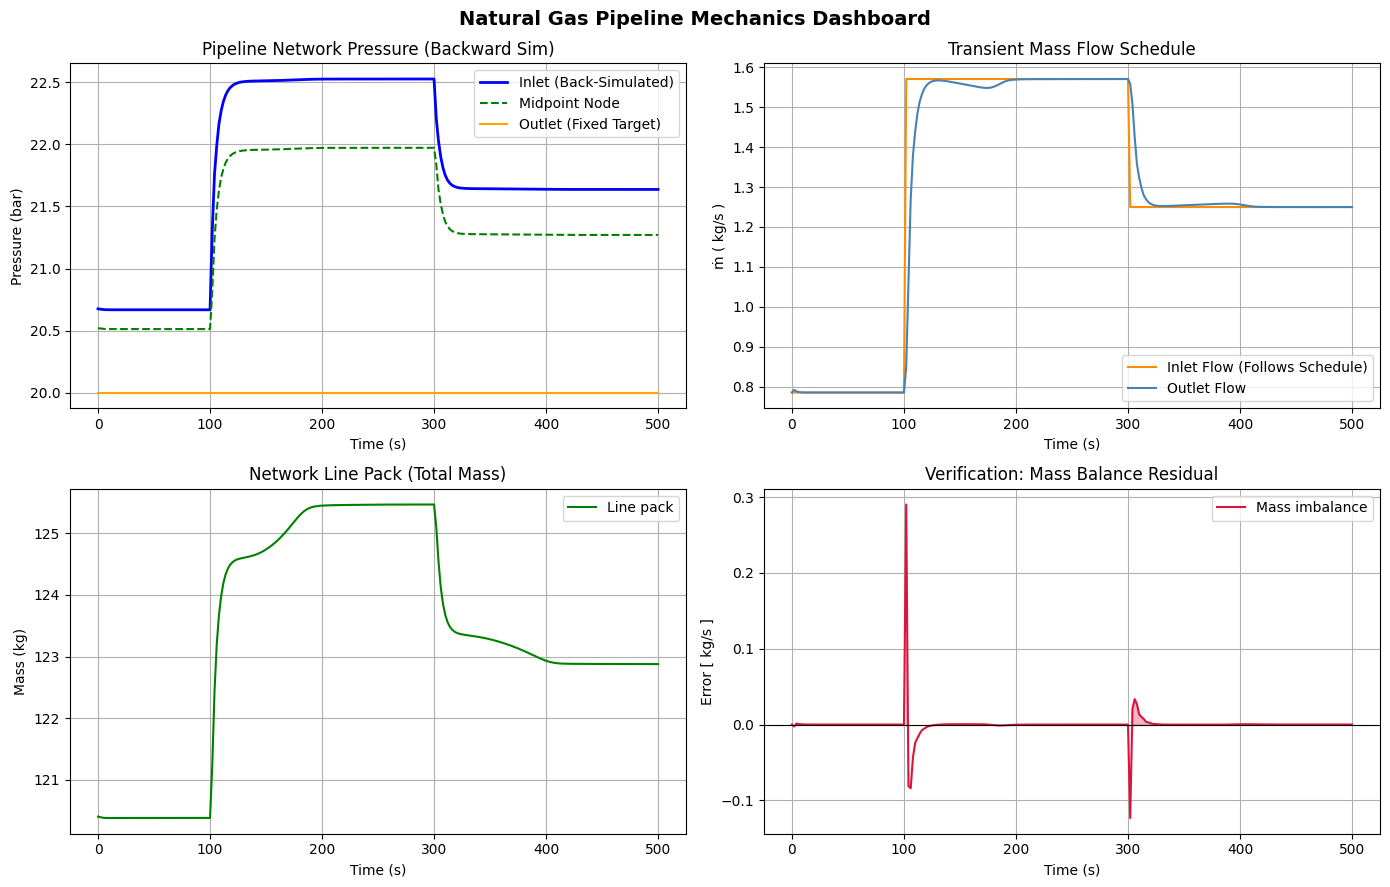

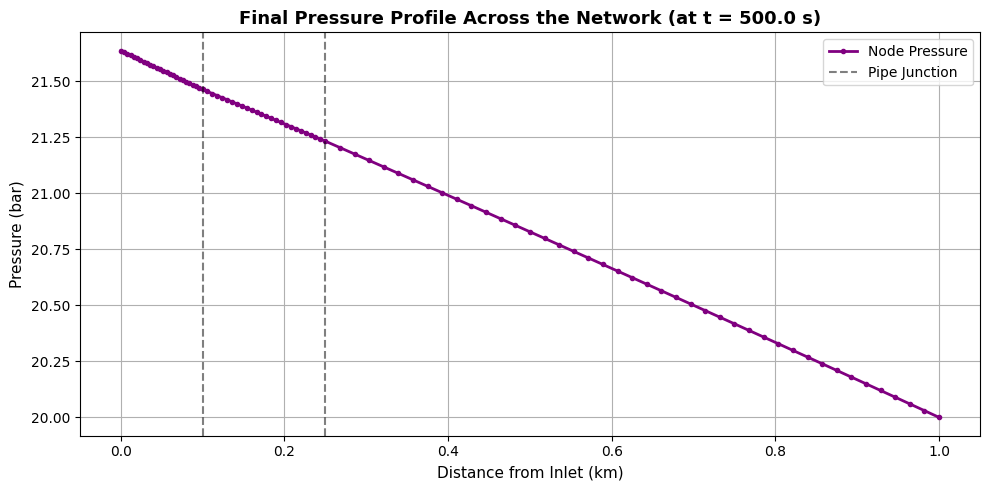

In [9]:
if len(history_t) > 0 and not np.isnan(history_P_inlet).all():
    history_t = np.array(history_t)
    history_mass_balance = np.array(history_mass_balance)
    
    # --- FIGURE 1: Mechanics Dashboard ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(history_t, np.array(history_P_inlet) / 1e5, label='Inlet (Back-Simulated)', color='blue', linewidth=2)
    axes[0, 0].plot(history_t, np.array(history_P_mid) / 1e5, label='Midpoint Node', color='green', ls='--')
    axes[0, 0].plot(history_t, np.array(history_P_outlet) / 1e5, label='Outlet (Fixed Target)', color='orange')
    axes[0, 0].set_title('Pipeline Network Pressure (Backward Sim)')
    axes[0, 0].set_xlabel('Time (s)'); axes[0, 0].set_ylabel('Pressure (bar)')
    axes[0, 0].legend(); axes[0, 0].grid(True)

    axes[0, 1].plot(history_t, history_M_inlet, color='darkorange', label='Inlet Flow (Follows Schedule)')
    axes[0, 1].plot(history_t, history_M_outlet, color='steelblue', label='Outlet Flow')
    axes[0, 1].set_title('Transient Mass Flow Schedule')
    axes[0, 1].set_xlabel('Time (s)'); axes[0, 1].set_ylabel('ṁ ( kg/s )')
    axes[0, 1].legend(); axes[0, 1].grid(True)

    axes[1, 0].plot(history_t, history_line_pack, color='green', label='Line pack')
    axes[1, 0].set_title('Network Line Pack (Total Mass)')
    axes[1, 0].set_xlabel('Time (s)'); axes[1, 0].set_ylabel('Mass (kg)')
    axes[1, 0].legend(); axes[1, 0].grid(True)

    axes[1, 1].plot(history_t, history_mass_balance, color='crimson', label='Mass imbalance')
    axes[1, 1].axhline(y=0, color='black', lw=0.8)
    axes[1, 1].fill_between(history_t, history_mass_balance, 0, where=(history_mass_balance > 0), alpha=0.3, color='crimson')
    axes[1, 1].set_title('Verification: Mass Balance Residual')
    axes[1, 1].set_xlabel('Time (s)'); axes[1, 1].set_ylabel('Error [ kg/s ]')
    axes[1, 1].legend(); axes[1, 1].grid(True)
    plt.suptitle(f'{gas.name} Pipeline Mechanics Dashboard', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- FIGURE 2: Final Spatial Profile ---
    plt.figure(figsize=(10, 5))
    plt.plot(x_coords / 1000, P / 1e5, color='purple', linewidth=2, marker='.', markersize=6, label='Node Pressure')
    for junc in junctions[:-1]:
        plt.axvline(x=junc / 1000, color='black', ls='--', alpha=0.5, label='Pipe Junction')
        
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    plt.title(f'Final Pressure Profile Across the Network (at t = {t_total} s)', fontsize=13, fontweight='bold')
    plt.xlabel('Distance from Inlet (km)', fontsize=11)
    plt.ylabel('Pressure (bar)', fontsize=11)
    plt.legend(by_label.values(), by_label.keys())
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    